# PolePredictor Project

Main goals: predict events and results.

Event types:
- Overtake between X and Y
- Driver X will pit
- Someone will crash
- Someone will spin
- Driver X will get fastest lap

## Predicting Results

Goals:
- X will finish ahead of Y
- X will earn n points
- X will win race
- X will be at top 10

Features:
- weather data
    - air temperature
    - humidity
    - pressure
    - rainfall
    - track temperature
    - wind direction (we need to calculate the "driving direction" in order to use this)
    - wind speed (we need to calculate the "driving direction" in order to use this)
- lap data
    - lap time
    - tyre type
    - tyre age
    - pit laps (get which laps the driver pitted)
- car data
    - drs usage (amount of time the driver had the DRS on)
    - brake/Throttle relation (check for the superposition strategy)
    - gear (we need to calculate weather or not the driver got the right gear changes)
    - rpm
    - speed
- pos data
    - off track time

## Imports and installs

In [ ]:
!pip install fastf1
!pip install scikit-learn
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import fastf1

## Playing around with the data

In [ ]:
abudhabi_2021 = fastf1.get_session(2021, 16, 'R')
abudhabi_2021.load()

core           INFO 	Loading data for Turkish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 77 completed the race distance 00:00.079000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['77', '33', '11', '16', '44', '10', '4', '55', '18', '31', '99', '

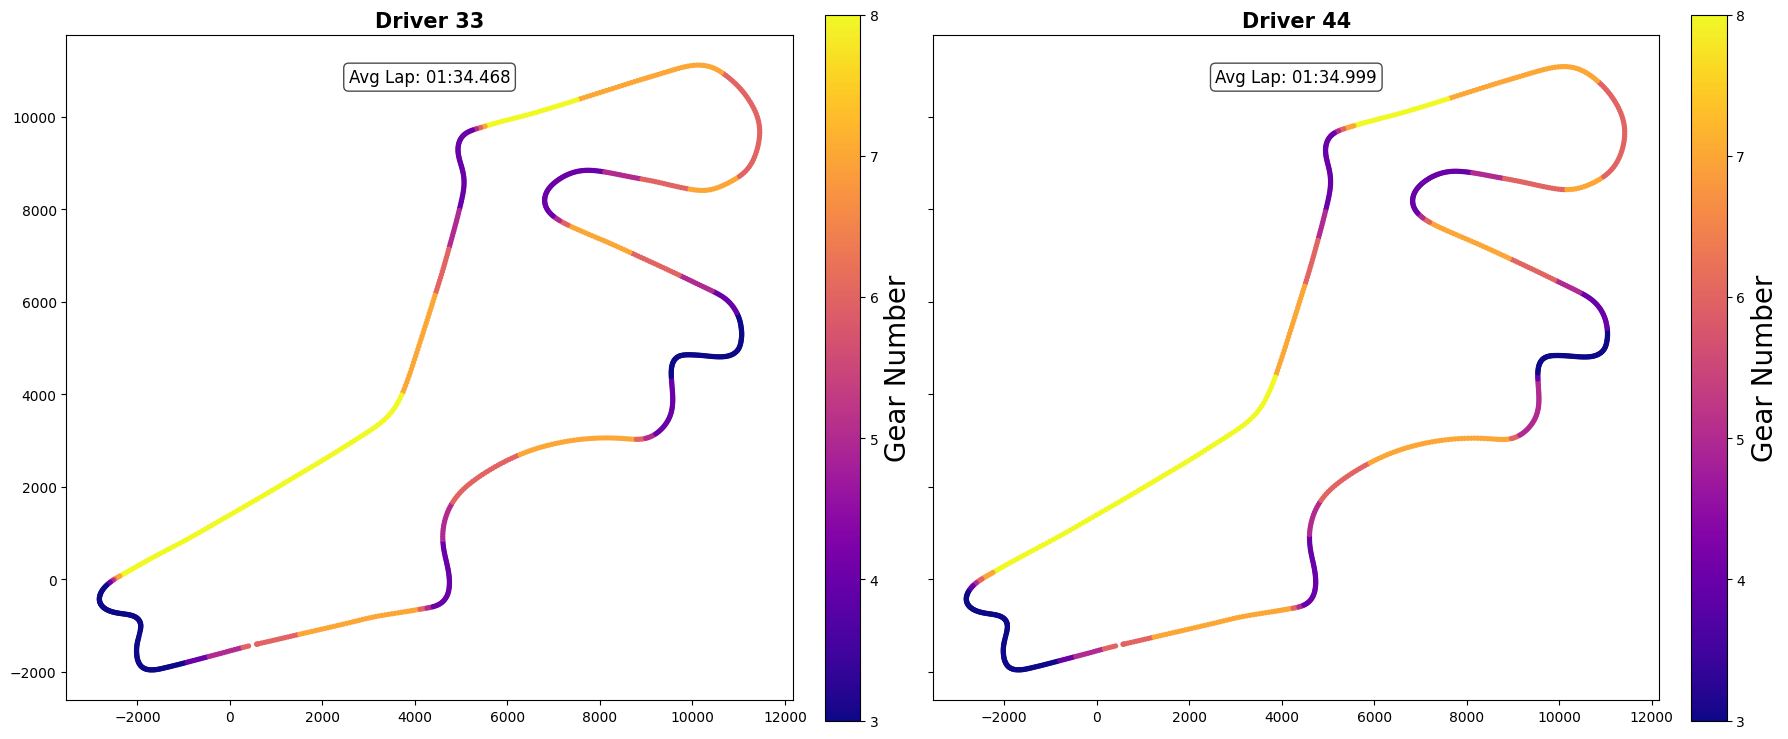

In [ ]:
def get_interpolated_lap(session, driver_number, lap_number, num_points=1000):
    laps = session.laps[session.laps["DriverNumber"] == driver_number]
    lap_data = laps.iloc[lap_number-1]
    lap_start = lap_data["LapStartTime"]
    lap_time = lap_data["LapTime"].total_seconds()
    lap_end = lap_start + lap_data["LapTime"]
    
    pos = session.pos_data[driver_number]
    car = session.car_data[driver_number]
    
    mask_pos = (pos["SessionTime"] >= lap_start) & (pos["SessionTime"] <= lap_end)
    mask_car = (car["SessionTime"] >= lap_start) & (car["SessionTime"] <= lap_end)
    
    raw_times_pos = (pos.loc[mask_pos, "SessionTime"] - lap_start).dt.total_seconds()
    raw_times_car = (car.loc[mask_car, "SessionTime"] - lap_start).dt.total_seconds()
    
    norm_times_pos = raw_times_pos / raw_times_pos.max()
    norm_times_car = raw_times_car / raw_times_car.max()
    
    target_grid = np.linspace(0, 1, num_points)
    
    interp_x = np.interp(target_grid, norm_times_pos, pos.loc[mask_pos, "X"])
    interp_y = np.interp(target_grid, norm_times_pos, pos.loc[mask_pos, "Y"])
    interp_g = np.interp(target_grid, norm_times_car, car.loc[mask_car, "nGear"])
    
    return interp_x, interp_y, interp_g, lap_time

def get_mean_data(driver_number, session):
    driver_laps = session.laps[session.laps["DriverNumber"] == driver_number]
    driver_laps = driver_laps[driver_laps['PitInTime'].isna() & driver_laps['PitOutTime'].isna()]
    
    all_x, all_y, all_g, all_l = [], [], [], []
    for i in range(len(driver_laps)):
        try:
            x, y, g, l = get_interpolated_lap(session, driver_number, i + 1)
            all_x.append(x)
            all_y.append(y)
            all_g.append(g)
            all_l.append(l)
        except Exception: 
            continue

    return {
        "x": np.mean(all_x, axis=0),
        "y": np.mean(all_y, axis=0),
        "g": np.round(np.mean(all_g, axis=0)),
        "l": np.mean(all_l)
    }

def plot_comparison(d1, d2, session):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
    
    drivers = [d1, d2]
    axes = [ax1, ax2]
    
    for driver, ax in zip(drivers, axes):
        data = get_mean_data(driver, session)
        points = ax.scatter(data['x'], data['y'], c=data['g'], cmap='plasma', s=8)
        cbar = plt.colorbar(points, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Gear Number', fontsize=20)
        unique_gears = np.unique(data['g'])
        cbar.set_ticks(unique_gears)
        cbar.set_ticklabels(unique_gears.astype(int))
        minutes, seconds = divmod(data['l'], 60)
        time_str = f"Avg Lap: {int(minutes):02d}:{seconds:06.3f}"
        ax.set_title(f"Driver {driver}", fontsize=15, fontweight='bold')
        ax.set_aspect('equal')
        ax.text(0.5, 0.95, time_str, transform=ax.transAxes, 
                ha='center', va='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_comparison("33", "44", abudhabi_2021)

## Correlation between average lap time and finishing position

In [ ]:
abudhabi_2024 = fastf1.get_session(2024, 16, 'R')
abudhabi_2024.load()

In [168]:
session = abudhabi_2024
df = pd.DataFrame(columns=["DriverNumber", "AverageLapTime"])
for driver in session.drivers:
    laps = session.laps[session.laps["DriverNumber"] == driver]
    lap_times = laps["LapTime"].dt.total_seconds()
    avg = lap_times.mean()
    df = pd.concat([df, pd.DataFrame([{"DriverNumber": driver, "AverageLapTime": avg}])], ignore_index=True)

r = session.results.loc[:, ["DriverNumber", "Position"]]
a = df.sort_values("AverageLapTime").reset_index(drop=True)

# adding a fake data
# a.loc[3, 'AverageLapTime'] = 80.0

for i in range(len(a)):
    d_number = int(r.iloc[i]['DriverNumber'])
    pos = int(r.iloc[i]['Position'])
    avg_lap_time = a.loc[i, 'AverageLapTime']
    print(f"Driver: {d_number:02d} | Pos: {pos:02d} | Avg Lap Time: ", end="")
    if i > 0 and avg_lap_time < a.loc[i-1, 'AverageLapTime']:
        print(f"\033[1;31m{avg_lap_time:.3f}\033[0m")
    elif i < len(a) - 1 and avg_lap_time > a.loc[i+1, 'AverageLapTime']:
        print(f"\033[1;33m{avg_lap_time:.3f}\033[0m")
    else:
        print(f"{avg_lap_time:.3f}")

Driver: 16 | Pos: 01 | Avg Lap Time: 84.542
Driver: 81 | Pos: 02 | Avg Lap Time: 84.592
Driver: 04 | Pos: 03 | Avg Lap Time: 84.658
Driver: 55 | Pos: 04 | Avg Lap Time: 84.837
Driver: 44 | Pos: 05 | Avg Lap Time: 84.973
Driver: 01 | Pos: 06 | Avg Lap Time: 85.258
Driver: 63 | Pos: 07 | Avg Lap Time: 85.291
Driver: 11 | Pos: 08 | Avg Lap Time: 85.564
Driver: 23 | Pos: 09 | Avg Lap Time: 85.642
Driver: 20 | Pos: 10 | Avg Lap Time: 85.815
Driver: 14 | Pos: 11 | Avg Lap Time: 85.834
Driver: 43 | Pos: 12 | Avg Lap Time: 86.022
Driver: 03 | Pos: 13 | Avg Lap Time: 86.076
Driver: 31 | Pos: 14 | Avg Lap Time: 86.411
Driver: 10 | Pos: 15 | Avg Lap Time: 86.521
Driver: 77 | Pos: 16 | Avg Lap Time: 86.691
Driver: 27 | Pos: 17 | Avg Lap Time: 86.761
Driver: 24 | Pos: 18 | Avg Lap Time: 86.938
Driver: 18 | Pos: 19 | Avg Lap Time: 87.005
Driver: 22 | Pos: 20 | Avg Lap Time: 90.953


/tmp/ipykernel_259131/3163207919.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{"DriverNumber": driver, "AverageLapTime": avg}])], ignore_index=True)


## Training a model to predict race winner 

In [27]:
global_driver_map = dict() # this will be filled dynamically

def merge_dataframes_filling_blanks(d1, d2):
    smaller = pd.DataFrame()
    larger = pd.DataFrame()
    if d1.shape[0] > d2.shape[0]:
        smaller = d2.copy()
        larger = d1.copy()
    else:
        smaller = d1.copy()
        larger = d2.copy()
    
    # interpolating with numpy
    time_target = larger["Time"]
    time_source = smaller["Time"]
    for col in smaller.columns:
        if col == "Time":
            continue
        larger[col] = np.interp(time_target, time_source, smaller[col])

    # # duplicating nearest with pandas
    # df_small = weather_data.sort_values('Time')
    # df_large = main_df.sort_values('Time')
    # df_aligned = pd.merge_asof(df_large, df_small, on='Time', direction='backward')
    # df_combined = df_aligned.interpolate(method='linear')
    # df_combined.describe()
    return larger

def populate_dataframe(main_df, session):
    
    aux_df = pd.DataFrame()
    
    # correspondence between DriverNumber and DriverName (for this session)
    local_driver_map = {driver[0]: driver[9] for driver in session.results.values}
    
    # adding lap data
    lap_data = session.laps.copy()
    lap_data = lap_data[
        lap_data["PitInTime"].isna()
        & lap_data["PitOutTime"].isna()
        & lap_data["LapTime"].notna()
        & lap_data["Time"].notna()
        & lap_data["DriverNumber"].notna()
    ]
    lap_data = lap_data[
        [
            "DriverNumber",
            "Time",
            "Position",
            "LapTime",
            "LapNumber",
            "Stint",
            "TyreLife",
        ]
    ]
    lap_data["Time"] = lap_data["Time"].dt.total_seconds()
    aux_df = pd.concat([aux_df, lap_data], axis=1)

    # adding weather data
    weather_data = session.weather_data.copy()
    weather_data.drop(columns=["Rainfall", "WindDirection", "WindSpeed"], inplace=True)
    weather_data["Time"] = weather_data["Time"].dt.total_seconds()
    # TODO: WindDirection and WindSpeed

    aux_df = merge_dataframes_filling_blanks(aux_df, weather_data)
    
    for col in main_df.columns:
        if main_df[col].dtype == 'timedelta64[ns]':
            main_df[col] = main_df[col].dt.total_seconds()
            
    # changing the local "drivernumber" to the global driverId
    aux_df["DriverName"] = aux_df["DriverNumber"].map(local_driver_map)
    for name in aux_df["DriverName"].unique():
        if name not in global_driver_map:
            global_driver_map[name] = len(global_driver_map) + 1
    aux_df["DriverId"] = aux_df["DriverName"].map(lambda name: global_driver_map.get(name, name))
    aux_df.drop(columns=["DriverName"], inplace=True)
    aux_df.drop(columns=["DriverNumber"], inplace=True)
    main_df = pd.concat([main_df, aux_df], ignore_index=True)

    return main_df

In [5]:
sessions = [
    fastf1.get_session(2022, 'Abu Dhabi', 'R'), 
    fastf1.get_session(2023, 'Abu Dhabi', 'R'), 
    fastf1.get_session(2024, 'Abu Dhabi', 'R'),
    # fastf1.get_session(2025, 'Abu Dhabi', 'R'),
]
for session in sessions:
    session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (1.34 GB) /home/matheus/.cache/fastf1


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '55', '63', '4', '31', '18', '3', '5', '22', '24', '23', '10', '77', '47', '20', '44', '6', '14']
core           INFO 	Loading data for Abu Dhabi Grand Prix - 

In [28]:
df = pd.DataFrame()
for session in sessions:
    session_df = pd.DataFrame()
    session_df = populate_dataframe(session_df, session)
    df = pd.concat([df, session_df], ignore_index=True)
    
X = df.drop(columns=["LapTime"])
y = df["LapTime"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)
df

,Time,Position,LapTime,LapNumber,Stint,TyreLife,AirTemp,Humidity,Pressure,TrackTemp,DriverId
0,3822.593,1.0,0 days 00:01:32.198000,1.0,1.0,1.0,28.700000,61.670928,1013.432907,34.765814,1
1,3913.134,1.0,0 days 00:01:30.541000,2.0,1.0,2.0,28.700000,61.838067,1013.416193,34.900000,1
2,4003.102,1.0,0 days 00:01:29.968000,3.0,1.0,3.0,28.633748,62.337478,1013.500000,34.366252,1
3,4093.470,1.0,0 days 00:01:30.368000,4.0,1.0,4.0,28.700000,62.156465,1013.500000,34.046940,1
4,4183.972,1.0,0 days 00:01:30.502000,5.0,1.0,5.0,28.564795,62.000000,1013.500000,34.000000,1
...,...,...,...,...,...,...,...,...,...,...,...
3107,8333.038,10.0,0 days 00:01:27.731000,54.0,3.0,22.0,25.900000,60.000000,1017.892594,29.300000,21
3108,8420.819,10.0,0 days 00:01:27.781000,55.0,3.0,23.0,25.900000,60.000000,1018.000000,29.400000,21
3109,8508.635,10.0,0 days 00:01:27.816000,56.0,3.0,24.0,25.900000,60.000000,1018.000000,29.400000,21
3110,8597.189,10.0,0 days 00:01:28.554000,57.0,3.0,25.0,25.900000,60.000000,1018.000000,29.300000,21


In [29]:
# get the rows where DriverID is not a number
non_numeric_rows = df[~df["DriverId"].apply(lambda x: isinstance(x, (int, float)) and not np.isnan(x))]
non_numeric_rows["DriverId"].unique()

array([], dtype=int64)

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_valid)
print("Linear Regression Performance:")
print("MSE:", mean_squared_error(y_valid, y_pred))
print("ACCURACY: ", model.score(X_valid, y_valid))

# ploting feature importance
# importances = np.abs(model.coef_)
# feature_names = X.columns
# indices = np.argsort(importances)[::-1]
# plt.figure(figsize=(12, 6))
# plt.bar(range(len(importances)), importances[indices], align='center')
# plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
# plt.title('Feature Importance (Linear Regression Coefficients)')
# plt.tight_layout()
# plt.show()

Linear Regression Performance:
MSE: 7.026767551175002e+18
ACCURACY:  0.2528984037552895


In [31]:
import torch
import torch.nn as nn

class TelemetryInterpolationModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(TelemetryInterpolationModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer: Processes the sequence
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Layer: Turns the LSTM output into a prediction (e.g., X, Y, or Speed)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )
        
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # We only care about the last time step's prediction
        out = self.fc(out[:, -1, :])
        return out

# Example parameters
model = TelemetryInterpolationModel(input_size=5, hidden_size=128, num_layers=2, output_size=1)

ModuleNotFoundError: No module named 'torch'

In [9]:
test_session = fastf1.get_session(2025, 'Abu Dhabi', 'R')
test_session.load()

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


In [ ]:
test_session_df = pd.DataFrame()
test_session_df = populate_dataframe(test_session_df, test_session)
X = test_session_df.drop(columns=["LapTime"])
y = test_session_df["LapTime"]
y_pred = model.predict(X)

test_session_df["PredictedAvgLapTime"] = y_pred
avg_lap_times = test_session_df.groupby("DriverId")["PredictedAvgLapTime"].mean().reset_index()
global_driver_map_inv = {v: k for k, v in global_driver_map.items()}
avg_lap_times["FullName"] = avg_lap_times["DriverId"].map(global_driver_map_inv)
avg_lap_times = test_session.results[["Position", "FullName"]].merge(avg_lap_times.drop_duplicates(), on="FullName", how="left")
avg_lap_times = avg_lap_times.sort_values("PredictedAvgLapTime").reset_index(drop=True)
avg_lap_times["PredictedPosition"] = avg_lap_times.index + 1
avg_lap_times = avg_lap_times.sort_values("Position").reset_index(drop=True)

for i in range(len(avg_lap_times)):
    name = f"{avg_lap_times.iloc[i]['FullName']}"
    pos = int(avg_lap_times.iloc[i]['Position'])
    pred_pos = int(avg_lap_times.iloc[i]['PredictedPosition'])
    print(f"Driver: {name:20s} | Result: {pos:02d} | Predicted: ", end="")
    if pred_pos != pos:
        print(f"\033[1;31m{pred_pos:02d}\033[0m")
    else:
        print(f"\033[1;32m{pred_pos:02d}\033[0m")    

Driver: Max Verstappen       | Result: 01 | Predicted: 03
Driver: Oscar Piastri        | Result: 02 | Predicted: 04
Driver: Lando Norris         | Result: 03 | Predicted: 01
Driver: Charles Leclerc      | Result: 04 | Predicted: 02
Driver: George Russell       | Result: 05 | Predicted: 05
Driver: Fernando Alonso      | Result: 06 | Predicted: 06
Driver: Esteban Ocon         | Result: 07 | Predicted: 08
Driver: Lewis Hamilton       | Result: 08 | Predicted: 07
Driver: Nico Hulkenberg      | Result: 09 | Predicted: 10
Driver: Lance Stroll         | Result: 10 | Predicted: 14
Driver: Gabriel Bortoleto    | Result: 11 | Predicted: 09
Driver: Oliver Bearman       | Result: 12 | Predicted: 12
Driver: Carlos Sainz         | Result: 13 | Predicted: 15
Driver: Yuki Tsunoda         | Result: 14 | Predicted: 11
Driver: Kimi Antonelli       | Result: 15 | Predicted: 17
Driver: Alexander Albon      | Result: 16 | Predicted: 13
Driver: Isack Hadjar         | Result: 17 | Predicted: 16
Driver: Liam L

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:26:07.469000,Finished,25.0,58.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,3.0,NaT,NaT,NaT,0 days 00:00:12.594000,Finished,18.0,58.0
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,3.0,3,2.0,NaT,NaT,NaT,0 days 00:00:16.572000,Finished,15.0,58.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,4,5.0,NaT,NaT,NaT,0 days 00:00:23.279000,Finished,12.0,58.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,5.0,5,4.0,NaT,NaT,NaT,0 days 00:00:48.563000,Finished,10.0,58.0
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:01:07.562000,Finished,8.0,58.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,7.0,7,8.0,NaT,NaT,NaT,0 days 00:01:09.876000,Finished,6.0,58.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,8.0,8,16.0,NaT,NaT,NaT,0 days 00:01:12.670000,Finished,4.0,58.0
27,27,N HULKENBERG,HUL,hulkenberg,Kick Sauber,01C00E,sauber,Nico,Hulkenberg,Nico Hulkenberg,...,9.0,9,18.0,NaT,NaT,NaT,0 days 00:01:19.014000,Finished,2.0,58.0
18,18,L STROLL,STR,stroll,Aston Martin,229971,aston_martin,Lance,Stroll,Lance Stroll,...,10.0,10,15.0,NaT,NaT,NaT,0 days 00:01:19.523000,Finished,1.0,58.0
